# Question 1: Setting Up the Conda Environment 

I created the Conda environment using the supplied YAML environment file and activated the environment named `Pattern_Recognition_Env`.

The following required packages were imported successfully:

- NumPy
- SciPy
- pandas
- scikit-learn (`sklearn`)
- Matplotlib
- seaborn

The screenshot below shows the active Conda environment and successful package-import verification.

![Conda environment verification](Environment_setup.png)

## Question 2: Feature Engineering and Preprocessing Pipeline

### Part A: Data Audit

The Titanic dataset is loaded and examined to understand its dimensions, data types, missing values, duplicate rows, and target-class distribution.

In [1]:
# Import 
import pandas as pd

In [2]:
# Load the dataset
data=pd.read_csv("titanic.csv")

# top 5 samples
print(f"First 5 samples:\n{data.head()} ")

First 5 samples:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

### 1.The number of observations and features.

In [3]:
# Report the number of observations and input features
number_of_observations = data.shape[0]
number_of_features = data.shape[1] - 1  # Exclude the target: Survived

print(f"Number of observations: {number_of_observations}")
print(f"Number of input features: {number_of_features}")

Number of observations: 891
Number of input features: 11


### 2.The data type of each column.

In [4]:
print(f"\nDatatype of each column:\n{data.dtypes} ")


Datatype of each column:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object 


### 3.The number and percentage of missing values in each column.

In [5]:
missing_value=data.isnull().sum()
missing_value_percentage=(missing_value/len(data))*100
print(f"Missing value\n{missing_value}\n\n\nMissing Value percentage:\n{missing_value_percentage} ")

Missing value
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Missing Value percentage:
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64 


### 4.The number of duplicated rows.

In [6]:
duplicate_rows = data.duplicated().sum()
print(f"Number of duplicated rows: {duplicate_rows}")

Number of duplicated rows: 0


### 5.The class distribution of Survived.

In [7]:
survived_count = data["Survived"].value_counts()
survived_percentage = data["Survived"].value_counts(normalize=True) * 100

print(f"Class count:\n{survived_count}")
print(f"\nClass percentage:\n{survived_percentage.round(2)}")

Class count:
Survived
0    549
1    342
Name: count, dtype: int64

Class percentage:
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64


### Target Class Balance Discussion

The target classes are not perfectly balanced. Approximately 61.62% of the passengers did not survive (`Survived = 0`), while 38.38% survived (`Survived = 1`). Therefore, the dataset has a moderate class imbalance toward the non-surviving class. However, both classes contain a substantial number of observations.

### Part B: Exploratory Analysis and Feature Relevance 
### 1. Distributions of the numerical features.

,count,mean,std,min,25%,50%,75%,max
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000


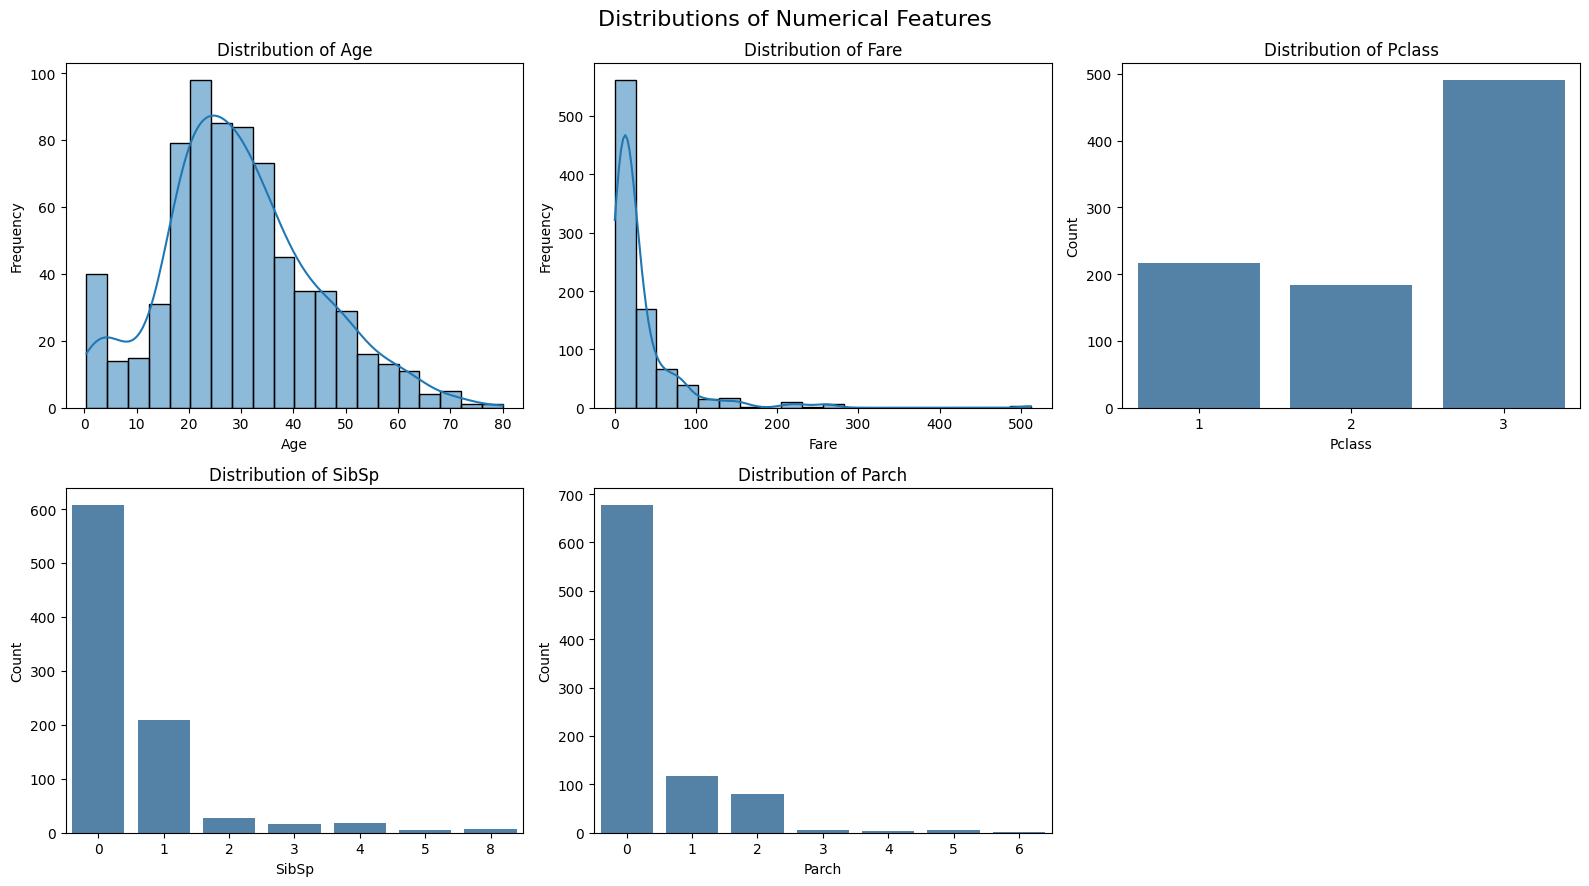

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

continuous_features = ["Age", "Fare"]
discrete_features = ["Pclass", "SibSp", "Parch"]
numerical_features = continuous_features + discrete_features

# Summary statistics
display(data[numerical_features].describe().T)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# Continuous numerical distributions
for index, feature in enumerate(continuous_features):
    sns.histplot(
        data=data,
        x=feature,
        bins=20,
        kde=True,
        ax=axes[index]
    )
    axes[index].set_title(f"Distribution of {feature}")
    axes[index].set_ylabel("Frequency")

# Discrete numerical distributions
for index, feature in enumerate(
    discrete_features,
    start=len(continuous_features)
):
    sns.countplot(
        data=data,
        x=feature,
        ax=axes[index],
        color="steelblue"
    )
    axes[index].set_title(f"Distribution of {feature}")
    axes[index].set_ylabel("Count")

# Delete unused subplot
fig.delaxes(axes[-1])

plt.suptitle("Distributions of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

### Numerical Feature Distribution Observations

- **Age:** Most passengers were approximately between 20 and 40 years old, with fewer children and older passengers. The count of 714 indicates that `Age` contains missing values.
- **Fare:** The distribution is strongly right-skewed. Most passengers paid relatively low fares, while a small number paid very high fares.
- **Pclass:** Most passengers travelled in third class (`Pclass = 3`).
- **SibSp:** Most passengers had no siblings or spouses aboard (`SibSp = 0`).
- **Parch:** Most passengers had no parents or children aboard (`Parch = 0`).

### 2. Frequency distribution(s) of important categorical features.


Frequency distribution of Sex:


,Count,Percentage (%)
Sex,,
male,577,64.76
female,314,35.24



Frequency distribution of Embarked:


,Count,Percentage (%)
Embarked,,
S,644,72.28
C,168,18.86
Q,77,8.64
NaN,2,0.22


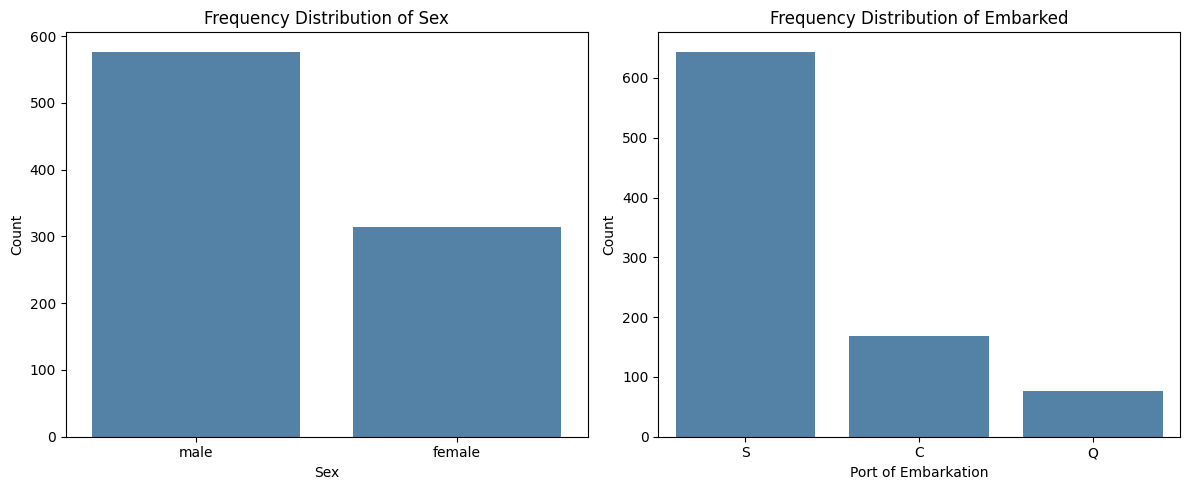

In [9]:
# Important categorical features
categorical_features = ["Sex", "Embarked"]

# Display frequency counts and percentages
for feature in categorical_features:
    frequency_count = data[feature].value_counts(dropna=False)
    frequency_percentage = (
        data[feature].value_counts(dropna=False, normalize=True) * 100
    ).round(2)

    frequency_table = pd.DataFrame({
        "Count": frequency_count,
        "Percentage (%)": frequency_percentage
    })

    print(f"\nFrequency distribution of {feature}:")
    display(frequency_table)

# Plot frequency distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(
    data=data,
    x="Sex",
    order=data["Sex"].value_counts().index,
    ax=axes[0],
    color="steelblue"
)
axes[0].set_title("Frequency Distribution of Sex")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Count")

sns.countplot(
    data=data,
    x="Embarked",
    order=data["Embarked"].value_counts().index,
    ax=axes[1],
    color="steelblue"
)
axes[1].set_title("Frequency Distribution of Embarked")
axes[1].set_xlabel("Port of Embarkation")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### Categorical Feature Frequency Observations

- **Sex:** Male passengers were the majority, accounting for 577 passengers (64.76%), while 314 passengers (35.24%) were female.
- **Embarked:** Most passengers embarked from Southampton (`S`), accounting for 644 passengers (72.28%). This was followed by Cherbourg (`C`) with 168 passengers (18.86%) and Queenstown (`Q`) with 77 passengers (8.64%).
- The `Embarked` feature contains 2 missing values (0.22%), which will require handling during preprocessing.

### 3. The relationship between selected features and Survived.


Survival summary by Sex:


,Passenger_Count,Survived_Count,Survival_Rate (%)
Sex,,,
female,314,233,74.20
male,577,109,18.89



Survival summary by Pclass:


,Passenger_Count,Survived_Count,Survival_Rate (%)
Pclass,,,
1,216,136,62.96
2,184,87,47.28
3,491,119,24.24



Survival summary by Embarked:


,Passenger_Count,Survived_Count,Survival_Rate (%)
Embarked,,,
C,168,93,55.36
Q,77,30,38.96
S,644,217,33.70
NaN,2,2,100.00


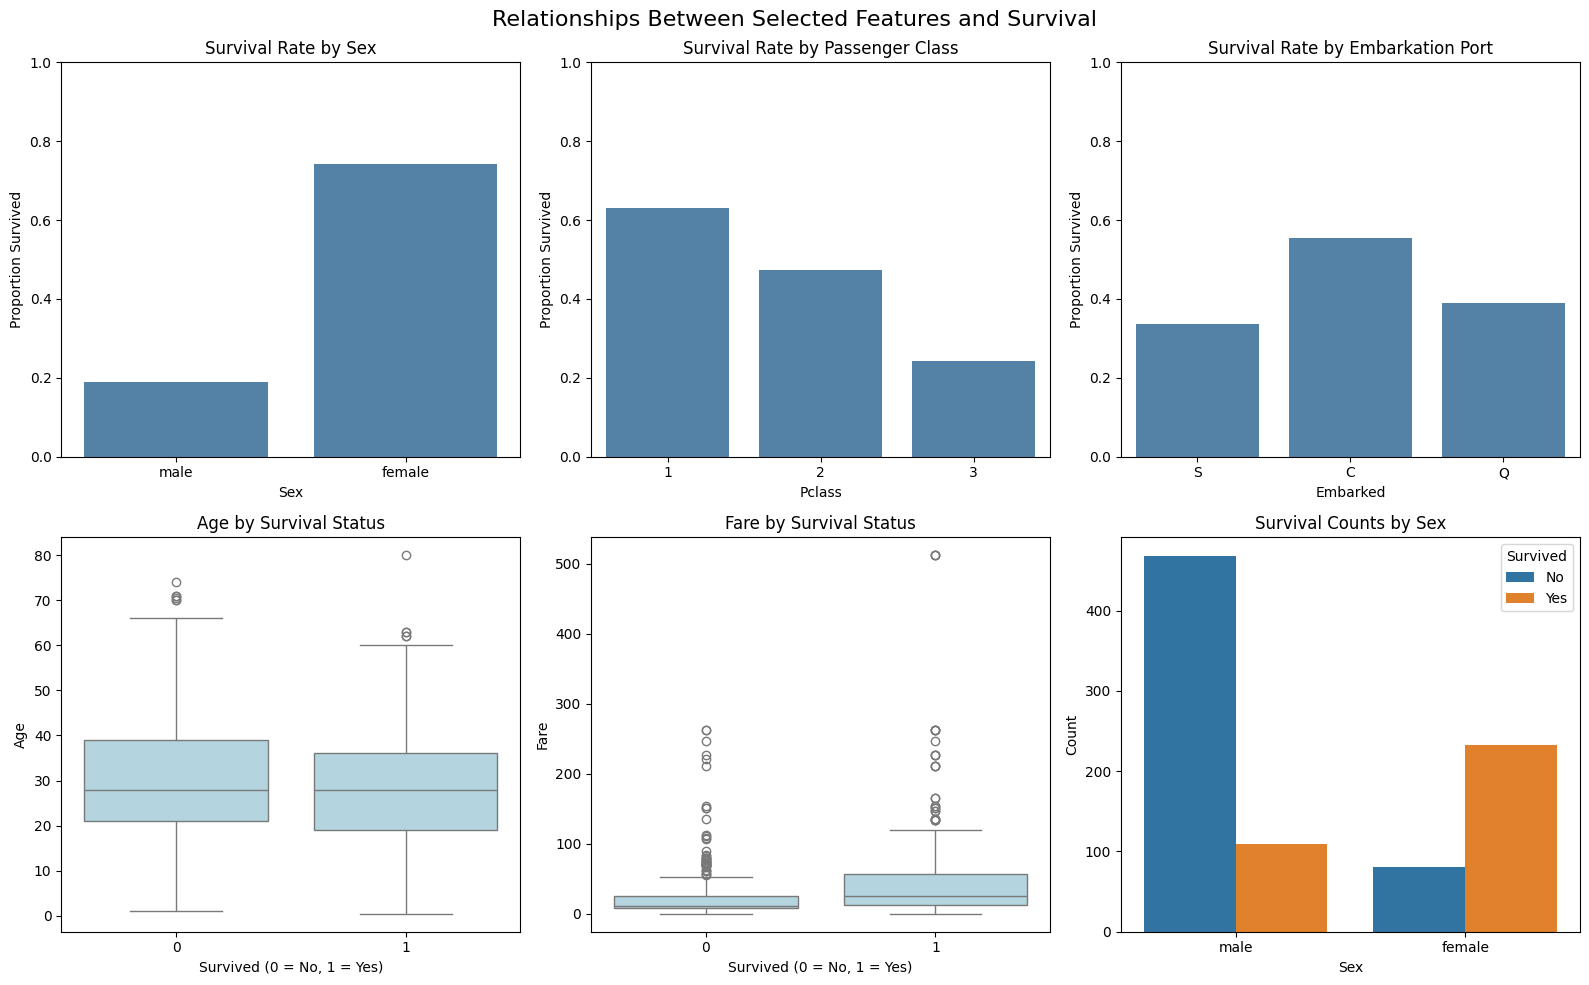

In [10]:
# Selected categorical features and their relationship with Survived
selected_categorical_features = ["Sex", "Pclass", "Embarked"]

for feature in selected_categorical_features:
    survival_summary = (
        data.groupby(feature, dropna=False)["Survived"]
        .agg(Passenger_Count="count", Survived_Count="sum", Survival_Rate="mean")
    )

    survival_summary["Survival_Rate (%)"] = (
        survival_summary["Survival_Rate"] * 100
    ).round(2)

    survival_summary = survival_summary.drop(columns="Survival_Rate")

    print(f"\nSurvival summary by {feature}:")
    display(survival_summary)


# Create plots showing relationships with Survived
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Survival rate by Sex
sns.barplot(
    data=data,
    x="Sex",
    y="Survived",
    errorbar=None,
    color="steelblue",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Survival Rate by Sex")
axes[0, 0].set_ylabel("Proportion Survived")
axes[0, 0].set_ylim(0, 1)

# Survival rate by Pclass
sns.barplot(
    data=data,
    x="Pclass",
    y="Survived",
    errorbar=None,
    color="steelblue",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Survival Rate by Passenger Class")
axes[0, 1].set_ylabel("Proportion Survived")
axes[0, 1].set_ylim(0, 1)

# Survival rate by Embarked
sns.barplot(
    data=data,
    x="Embarked",
    y="Survived",
    errorbar=None,
    color="steelblue",
    ax=axes[0, 2]
)
axes[0, 2].set_title("Survival Rate by Embarkation Port")
axes[0, 2].set_ylabel("Proportion Survived")
axes[0, 2].set_ylim(0, 1)

# Age distribution by survival status
sns.boxplot(
    data=data,
    x="Survived",
    y="Age",
    color="lightblue",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Age by Survival Status")
axes[1, 0].set_xlabel("Survived (0 = No, 1 = Yes)")

# Fare distribution by survival status
sns.boxplot(
    data=data,
    x="Survived",
    y="Fare",
    color="lightblue",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Fare by Survival Status")
axes[1, 1].set_xlabel("Survived (0 = No, 1 = Yes)")

# Survival counts by Sex
sns.countplot(
    data=data,
    x="Sex",
    hue="Survived",
    ax=axes[1, 2]
)
axes[1, 2].set_title("Survival Counts by Sex")
axes[1, 2].set_ylabel("Count")
axes[1, 2].legend(title="Survived", labels=["No", "Yes"])

plt.suptitle("Relationships Between Selected Features and Survival", fontsize=16)
plt.tight_layout()
plt.show()

### Relationships Between Selected Features and Survival

- **Sex:** Female passengers had a substantially higher survival rate (74.20%) than male passengers (18.89%). Therefore, `Sex` appears strongly related to survival.
- **Pclass:** First-class passengers had the highest survival rate (62.96%), followed by second-class passengers (47.28%) and third-class passengers (24.24%). Survival therefore decreased as passenger class changed from first to third.
- **Embarked:** Passengers who embarked at Cherbourg (`C`) had the highest observed survival rate (55.36%), followed by Queenstown (`Q`) at 38.96% and Southampton (`S`) at 33.70%.
- **Age:** The age distributions of survivors and non-survivors overlap considerably, although survivors have a slightly lower lower quartile. Therefore, the relationship between `Age` and survival is less pronounced in this plot.
- **Fare:** Survivors generally paid higher fares than non-survivors. However, both groups contain several high-fare outliers.
- The two passengers with missing `Embarked` values both survived, producing a 100% survival rate for that group. Because this group contains only two passengers, this rate should not be treated as a reliable pattern.

### 4. A correlation matrix for the numerical features.

# Numerical input features and target
correlation_columns = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

# Calculate the Pearson correlation matrix
correlation_matrix = data[correlation_columns].corr()

# Display the correlation values
display(correlation_matrix.round(2))

# Plot the correlation heatmap
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

### Correlation Matrix Observations

- `Pclass` has a moderate negative correlation with `Survived` (-0.34). This indicates that survival tended to decrease as the class number increased from first class to third class.
- `Fare` has a positive correlation with `Survived` (0.26), suggesting that passengers who paid higher fares were somewhat more likely to survive.
- `Age`, `SibSp`, and `Parch` have weak linear correlations with `Survived`.
- `Pclass` and `Fare` have a moderate negative correlation (-0.55), as first-class passengers generally paid higher fares.
- `SibSp` and `Parch` have a moderate positive correlation (0.41), which is reasonable because both describe family relationships aboard the ship.
- Weak Pearson correlation does not necessarily mean that a feature is irrelevant. A feature may have a nonlinear relationship with survival or may be useful through interactions with other features.

### 5. An examination of unusually sparse, high-cardinality, redundant, identifier-like, or potentially irrelevant features.

In [11]:
# Original predictor columns (exclude the target)
predictor_columns = data.columns.drop("Survived")

# General feature examination
feature_examination = pd.DataFrame({
    "Data Type": data[predictor_columns].dtypes.astype(str),
    "Missing Count": data[predictor_columns].isnull().sum(),
    "Missing Percentage (%)": (
        data[predictor_columns].isnull().mean() * 100
    ).round(2),
    "Unique Values": data[predictor_columns].nunique(dropna=True),
    "Unique Percentage (%)": (
        data[predictor_columns].nunique(dropna=True) / len(data) * 100
    ).round(2)
})

display(feature_examination)
# Examine identifier-like and high-cardinality features
special_features = ["PassengerId", "Name", "Ticket", "Cabin"]

high_cardinality_summary = pd.DataFrame({
    "Unique Values": data[special_features].nunique(dropna=True),
    "Unique Percentage (%)": (
        data[special_features].nunique(dropna=True) / len(data) * 100
    ).round(2),
    "Missing Percentage (%)": (
        data[special_features].isnull().mean() * 100
    ).round(2)
})

display(high_cardinality_summary)

# Most frequent non-missing ticket and cabin values
print("Most frequent Ticket values:")
display(data["Ticket"].value_counts().head(10).to_frame("Count"))

print("Most frequent Cabin values:")
display(data["Cabin"].value_counts().head(10).to_frame("Count"))

# Examine Cabin sparsity and whether cabin information is available
cabin_examination = data.assign(
    Cabin_Known=data["Cabin"].notna().map({
        True: "Known",
        False: "Missing"
    })
)

cabin_summary = (
    cabin_examination.groupby("Cabin_Known")["Survived"]
    .agg(Passenger_Count="count", Survived_Count="sum", Survival_Rate="mean")
)

cabin_summary["Survival Rate (%)"] = (
    cabin_summary["Survival_Rate"] * 100
).round(2)

cabin_summary = cabin_summary.drop(columns="Survival_Rate")

display(cabin_summary)

# Examine the relationship between SibSp and Parch
family_correlation = data[["SibSp", "Parch"]].corr()
display(family_correlation.round(2))

# Check a possible combined family-size feature
family_examination = data.assign(
    FamilySize=data["SibSp"] + data["Parch"] + 1
)

family_size_summary = (
    family_examination.groupby("FamilySize")["Survived"]
    .agg(Passenger_Count="count", Survival_Rate="mean")
)

family_size_summary["Survival Rate (%)"] = (
    family_size_summary["Survival_Rate"] * 100
).round(2)

family_size_summary = family_size_summary.drop(columns="Survival_Rate")

display(family_size_summary)

# Extract temporary features for examination only
temporary_features = pd.DataFrame(index=data.index)

# Extract passenger title from Name
temporary_features["Title"] = (
    data["Name"]
    .str.extract(r",\s*([^.]*)\.", expand=False)
    .str.strip()
)

# Extract deck letter from Cabin
temporary_features["Deck"] = (
    data["Cabin"]
    .str.extract(r"([A-Za-z])", expand=False)
    .str.upper()
    .fillna("Unknown")
)

print("Frequency of extracted titles:")
display(temporary_features["Title"].value_counts().to_frame("Count"))

print("Frequency of extracted cabin decks:")
display(temporary_features["Deck"].value_counts().to_frame("Count"))

,Data Type,Missing Count,Missing Percentage (%),Unique Values,Unique Percentage (%)
PassengerId,int64,0,0.00,891,100.00
Pclass,int64,0,0.00,3,0.34
Name,str,0,0.00,891,100.00
Sex,str,0,0.00,2,0.22
Age,float64,177,19.87,88,9.88
SibSp,int64,0,0.00,7,0.79
Parch,int64,0,0.00,7,0.79
Ticket,str,0,0.00,681,76.43
Fare,float64,0,0.00,248,27.83
Cabin,str,687,77.10,147,16.50


,Unique Values,Unique Percentage (%),Missing Percentage (%)
PassengerId,891,100.00,0.0
Name,891,100.00,0.0
Ticket,681,76.43,0.0
Cabin,147,16.50,77.1


Most frequent Ticket values:


,Count
Ticket,
347082,7
1601,7
CA. 2343,7
3101295,6
CA 2144,6
347088,6
382652,5
S.O.C. 14879,5
349909,4


Most frequent Cabin values:


...

,Passenger_Count,Survival Rate (%)
FamilySize,,
1,537,30.35
2,161,55.28
3,102,57.84
4,29,72.41
5,15,20.00
6,22,13.64
7,12,33.33
8,6,0.00
11,7,0.00


Frequency of extracted titles:


,Count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Major,2
Mlle,2
Col,2


Frequency of extracted cabin decks:


,Count
Deck,
Unknown,687
C,59
B,47
D,33
E,32
A,15
F,13
G,4
T,1


### Examination of Special Features

- **PassengerId:** This feature has 891 unique values, meaning every passenger has a different identifier. It is identifier-like and does not directly describe passenger characteristics, so it can be dropped.
- **Name:** All 891 names are unique, making the original feature high-cardinality. However, useful information such as passenger title (`Mr`, `Mrs`, `Miss`, and `Master`) can be extracted before dropping the original name.
- **Ticket:** The feature has 681 unique values (76.43%), so it has high cardinality. Some tickets are shared by multiple passengers, which may represent travelling groups. The original ticket value is unsuitable for direct one-hot encoding but could be transformed into ticket-group information.
- **Cabin:** This feature is unusually sparse because 687 values (77.10%) are missing. However, passengers with known cabin information had a higher observed survival rate than those with missing cabin information. Therefore, it may be transformed into a cabin-known indicator or deck category rather than used in its original form.
- **SibSp and Parch:** These features have a moderate positive correlation of 0.41 and both describe family relationships aboard. They can be combined into `FamilySize = SibSp + Parch + 1`. The survival rates also vary across family sizes.
- **Extracted features:** The title extracted from `Name` reduces the feature to meaningful categories. The deck extracted from `Cabin` may preserve useful information, although the large `Unknown` category must be considered.
- **Potentially irrelevant original features:** `PassengerId` has no direct descriptive meaning, while the original `Name`, `Ticket`, and `Cabin` features are unsuitable for direct use because of high cardinality or missingness. These features should therefore be dropped or transformed with justification.

### Feature-Decision Table

| Original Feature | Keep, Drop, or Transform | Reason |
|---|---|---|
| `PassengerId` | Drop | It is a unique passenger identifier and does not directly describe passenger characteristics. |
| `Pclass` | Keep | Passenger class represents socioeconomic and travel status, and survival rates differ across classes. |
| `Name` | Transform | The original values are unique and high-cardinality, but passenger titles such as Mr, Mrs, Miss, and Master can be extracted. |
| `Sex` | Keep | Survival rates differ substantially by sex, making it an important categorical predictor. |
| `Age` | Keep | Age may contain useful survival information. Its missing values will require imputation. |
| `SibSp` | Transform | It describes family relationships and can be combined with `Parch` to create `FamilySize`. |
| `Parch` | Transform | It describes family relationships and can be combined with `SibSp` to create `FamilySize`. |
| `Ticket` | Drop | It has high cardinality, and using the original ticket numbers would produce many sparse categories. |
| `Fare` | Keep | Fare may represent passengers' economic or travel status, and survivors generally paid higher fares. |
| `Cabin` | Transform | It has 77.10% missing values, but it can be converted into a simpler `CabinKnown` indicator. |
| `Embarked` | Keep | Survival rates differ across embarkation ports. Its two missing values will require imputation. |

### Correlation Matrix Observations

- `Pclass` has a moderate negative correlation with `Survived` (-0.34), indicating that survival was generally lower for passengers in higher-numbered classes.
- `Fare` has a positive correlation with `Survived` (0.26), suggesting that passengers who paid higher fares were somewhat more likely to survive.
- `Age`, `SibSp`, and `Parch` have weak linear correlations with `Survived`. However, weak Pearson correlation alone does not mean these features are irrelevant because they may have nonlinear relationships or interact with other features.
- `Pclass` and `Fare` have a moderate negative correlation (-0.55), while `SibSp` and `Parch` have a moderate positive correlation (0.41).

## Part C: Train-Test Split

In [12]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Separate the predictors and target
X = data.drop(columns="Survived")
y = data["Survived"]

# Create an 80% training and 20% test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shapes of the resulting datasets
print("Original predictor shape:", X.shape)
print("Original target shape:", y.shape)

print("\nTraining predictor shape:", X_train.shape)
print("Training target shape:", y_train.shape)

print("\nTest predictor shape:", X_test.shape)
print("Test target shape:", y_test.shape)

# Compare target-class distributions
class_distribution = pd.DataFrame({
    "Complete Dataset (%)": y.value_counts(normalize=True).sort_index() * 100,
    "Training Set (%)": y_train.value_counts(normalize=True).sort_index() * 100,
    "Test Set (%)": y_test.value_counts(normalize=True).sort_index() * 100
}).round(2)

display(class_distribution)

# Verify that the training and test indices do not overlap
overlapping_indices = X_train.index.intersection(X_test.index)

print("Number of overlapping indices:", len(overlapping_indices))

Original predictor shape: (891, 11)
Original target shape: (891,)

Training predictor shape: (712, 11)
Training target shape: (712,)

Test predictor shape: (179, 11)
Test target shape: (179,)


,Complete Dataset (%),Training Set (%),Test Set (%)
Survived,,,
0,61.62,61.66,61.45
1,38.38,38.34,38.55


Number of overlapping indices: 0


## Part D: Feature Engineering

In [13]:
# Feature-engineering function
def engineer_features(df):
    df_engineered = df.copy()

    # 1. Total number of family members travelling together,
    # including the passenger
    df_engineered["FamilySize"] = (
        df_engineered["SibSp"] + df_engineered["Parch"] + 1
    )

    # 2. Extract the passenger's title from Name
    df_engineered["Title"] = (
        df_engineered["Name"]
        .str.extract(r",\s*([^.]*)\.", expand=False)
        .str.strip()
    )

    # 3. Indicate whether cabin information is available
    df_engineered["CabinKnown"] = (
        df_engineered["Cabin"].notna().astype(int)
    )

    # Remove original features identified as redundant or unsuitable
    columns_to_drop = [
        "PassengerId",
        "Name",
        "SibSp",
        "Parch",
        "Ticket",
        "Cabin"
    ]

    df_engineered = df_engineered.drop(columns=columns_to_drop)

    return df_engineered
# Apply feature engineering separately
X_train_engineered = engineer_features(X_train)
X_test_engineered = engineer_features(X_test)

# Check the results
print("Training shape before feature engineering:", X_train.shape)
print("Training shape after feature engineering:", X_train_engineered.shape)

print("\nTest shape before feature engineering:", X_test.shape)
print("Test shape after feature engineering:", X_test_engineered.shape)

print("\nEngineered predictor columns:")
print(X_train_engineered.columns.tolist())

display(X_train_engineered.head())

Training shape before feature engineering: (712, 11)
Training shape after feature engineering: (712, 8)

Test shape before feature engineering: (179, 11)
Test shape after feature engineering: (179, 8)

Engineered predictor columns:
['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'Title', 'CabinKnown']


,Pclass,Sex,Age,Fare,Embarked,FamilySize,Title,CabinKnown
692,3,male,NaN,56.4958,S,1,Mr,0
481,2,male,NaN,0.0000,S,1,Mr,0
527,1,male,NaN,221.7792,S,1,Mr,1
855,3,female,18.0,9.3500,S,2,Mrs,0
801,2,female,31.0,26.2500,S,3,Mrs,0


### Feature Engineering Explanation

Three derived features were created: `FamilySize`, `Title`, and `CabinKnown`. The feature engineering was applied separately to the training and test predictors after the train-test split.

#### 1. `FamilySize`

**Calculation:**

`FamilySize = SibSp + Parch + 1`

`SibSp` represents the number of siblings or spouses travelling with the passenger, while `Parch` represents the number of parents or children. One is added to include the passenger.

**Why it may be useful:**

Family size may affect survival because passengers travelling alone, in small families, and in large families may have experienced different evacuation outcomes. Combining the two family-related columns provides a direct measure of the passenger's total family group size.

**Redundant original features:**

For this workflow, `SibSp` and `Parch` are removed after creating `FamilySize` because their combined information is represented by the new feature.

#### 2. `Title`

**Calculation:**

`Title` is extracted from the passenger's `Name`. For example, a name containing “Mrs.” produces the title `Mrs`.

**Why it may be useful:**

Titles such as `Mr`, `Mrs`, `Miss`, and `Master` may indirectly represent characteristics such as sex, age group, marital status, or social position. These characteristics may be associated with survival priority during evacuation.

**Redundant original feature:**

The original `Name` becomes unnecessary after extracting `Title`. Individual names are also unsuitable for direct encoding because all 891 names are unique.

#### 3. `CabinKnown`

**Calculation:**

`CabinKnown` is assigned a value of `1` when cabin information is available and `0` when it is missing.

**Why it may be useful:**

The exploratory analysis showed different survival rates between passengers with known and missing cabin information. Cabin availability may indirectly reflect passenger class, accommodation location, or the quality of available passenger records.

**Redundant original feature:**

The original `Cabin` feature is removed because 77.10% of its values are missing and its individual cabin values have relatively high cardinality. `CabinKnown` preserves a simpler potentially useful signal.

#### Other Removed Features

`PassengerId` is removed because it is only an identifier. `Ticket` is removed because its original values have high cardinality and would produce many sparse encoded categories.

After feature engineering, the training set contains 712 observations and 8 predictors, while the test set contains 179 observations and the same 8 predictors.

## Part E: Preprocessing Pipeline

In [14]:
# Separate numerical and categorical features
numerical_features = [
    "Pclass",
    "Age",
    "Fare",
    "FamilySize",
    "CabinKnown"
]

categorical_features = [
    "Sex",
    "Embarked",
    "Title"
]
# Import preprocessing tools
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical preprocessing:
# 1. Replace missing values with the training median
# 2. Standardize the numerical features
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing:
# 1. Replace missing values with the most frequent training category
# 2. Apply one-hot encoding
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# Apply the appropriate pipeline to each feature type
column_transformer = ColumnTransformer(
    transformers=[
        ("numerical", numerical_pipeline, numerical_features),
        ("categorical", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

# Reusable preprocessing pipeline
preprocessing_pipeline = Pipeline(steps=[
    ("preprocessor", column_transformer)
])

# Fit all preprocessing rules using only the training data
X_train_preprocessed = preprocessing_pipeline.fit_transform(
    X_train_engineered
)

# Apply the already-fitted rules to the test data
X_test_preprocessed = preprocessing_pipeline.transform(
    X_test_engineered
)
# Obtain the transformed feature names
feature_names = (
    preprocessing_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

print("Training shape before preprocessing:",
      X_train_engineered.shape)

print("Training shape after preprocessing:",
      X_train_preprocessed.shape)

print("\nTest shape before preprocessing:",
      X_test_engineered.shape)

print("Test shape after preprocessing:",
      X_test_preprocessed.shape)

print("\nNumber of transformed feature names:",
      len(feature_names))

print("\nTransformed feature names:")
print(feature_names)

import numpy as np

print(
    "Missing values in preprocessed training data:",
    np.isnan(X_train_preprocessed).sum()
)

print(
    "Missing values in preprocessed test data:",
    np.isnan(X_test_preprocessed).sum()
)

print(
    "All training values are finite:",
    np.isfinite(X_train_preprocessed).all()
)

print(
    "All test values are finite:",
    np.isfinite(X_test_preprocessed).all()
)
# Convert transformed arrays to DataFrames for inspection
X_train_preprocessed_df = pd.DataFrame(
    X_train_preprocessed,
    columns=feature_names,
    index=X_train_engineered.index
)

X_test_preprocessed_df = pd.DataFrame(
    X_test_preprocessed,
    columns=feature_names,
    index=X_test_engineered.index
)

display(X_train_preprocessed_df.head())

Training shape before preprocessing: (712, 8)
Training shape after preprocessing: (712, 24)

Test shape before preprocessing: (179, 8)
Test shape after preprocessing: (179, 24)

Number of transformed feature names: 24

Transformed feature names:
['numerical__Pclass' 'numerical__Age' 'numerical__Fare'
 'numerical__FamilySize' 'numerical__CabinKnown' 'categorical__Sex_female'
 'categorical__Sex_male' 'categorical__Embarked_C'
 'categorical__Embarked_Q' 'categorical__Embarked_S'
 'categorical__Title_Col' 'categorical__Title_Don' 'categorical__Title_Dr'
 'categorical__Title_Jonkheer' 'categorical__Title_Lady'
 'categorical__Title_Major' 'categorical__Title_Master'
 'categorical__Title_Miss' 'categorical__Title_Mlle'
 'categorical__Title_Mr' 'categorical__Title_Mrs' 'categorical__Title_Ms'
 'categorical__Title_Rev' 'categorical__Title_Sir']
Missing values in preprocessed training data: 0
Missing values in preprocessed test data: 0
All training values are finite: True
All test values are fin

,numerical__Pclass,numerical__Age,numerical__Fare,numerical__FamilySize,numerical__CabinKnown,categorical__Sex_female,categorical__Sex_male,categorical__Embarked_C,categorical__Embarked_Q,categorical__Embarked_S,...,categorical__Title_Lady,categorical__Title_Major,categorical__Title_Master,categorical__Title_Miss,categorical__Title_Mlle,categorical__Title_Mr,categorical__Title_Mrs,categorical__Title_Ms,categorical__Title_Rev,categorical__Title_Sir
692,0.829568,-0.081135,0.513812,-0.556339,-0.538382,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
481,-0.370945,-0.081135,-0.662563,-0.556339,-0.538382,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
527,-1.571457,-0.081135,3.955399,-0.556339,1.857418,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
855,0.829568,-0.887827,-0.467874,0.073412,-0.538382,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
801,-0.370945,0.110934,-0.115977,0.703162,-0.538382,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


### Preprocessing Pipeline

The engineered predictors were separated into numerical and categorical features.

For numerical features, missing values are replaced using the median calculated from the training data. Median imputation is appropriate because numerical features such as `Fare` and `FamilySize` may be skewed or contain extreme values. The numerical features are then standardized using `StandardScaler`.

For categorical features, missing values are replaced with the most frequent category calculated from the training data. The categorical features are then converted into numerical indicator columns using one-hot encoding.

The encoder uses `handle_unknown="ignore"`, which allows the pipeline to process categories that appear in the test data but were not present in the training data without producing an error.

The pipeline is fitted using `X_train_engineered` only. The fitted imputation values, scaling parameters, and encoding categories are then applied to `X_test_engineered` using `transform()`. Therefore, the test data does not influence any fitted preprocessing operation.

### Justification of Preprocessing Choices

Median imputation is used for numerical features because it is less sensitive to skewness and extreme values than mean imputation. Importantly, the median is learned only from the training data.

Most-frequent imputation is used for categorical features because it replaces missing values with a valid existing category. This is reasonable for `Embarked`, which contains only two missing values. The most frequent category is also learned only from the training data.

`StandardScaler` is used because the numerical features have substantially different measurement scales. For example, `Fare` has a much larger range than `CabinKnown`. Scaling gives the numerical features approximately zero mean and unit variance, preventing features with large numerical magnitudes from dominating scale-sensitive models. The scaling parameters are calculated only from the training data.

One-hot encoding is appropriate because `Sex`, `Embarked`, and `Title` are categorical variables without a continuous numerical scale. `handle_unknown="ignore"` ensures that a category found only in future or test data does not cause an error.

All learned preprocessing operations are contained inside the pipeline. The pipeline is fitted using only the training predictors, while the test predictors are processed using `transform()` without refitting.